# Exercise I: Exploratory Data Analysis (EDA)

## Learning objectives

By the end of this exercise, you should be able to:

- Inspect the dimensions and variables of a dataset
- Distinguish categorical and numerical variables
- Identify missing values and unusual observations
- Visualize univariate and multivariate distributions
- Detect potential confounding variables
- Formulate questions for subsequent predictive analysis


### Before we begin

We will be using data from the Autism Brain Imaging Data Exchange II (ABIDE II). 
When we load data or perform actions that are less relevant for the current session, 
we will sometimes hide code cells to make the notebook simpler. 
However, you can check them out and expand your knowledge! 



## 1. Importing and data loading

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Interactive props
import ipywidgets as widgets
from IPython.display import display, clear_output

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

sns.set_theme(style="whitegrid")

```{dropdown} Loading the ABIDE-II phenotypic data

The [Autism Brain Imaging Data Exchange II (ABIDE-II)](https://fcon_1000.projects.nitrc.org/indi/abide/abide_II.html) combines neuroimaging and phenotypic data collected across 19 international research sites. The complete phenotypic table contains several hundred variables, including demographic information, diagnostic assessments, cognitive scores, behavioral questionnaires, and acquisition-related variables.

The meaning and coding of each variable are documented in the official [ABIDE-II Phenotypic Data Legend](https://fcon_1000.projects.nitrc.org/indi/abide/ABIDEII_Data_Legend.pdf).

The complete ABIDE-II phenotypic dataset contains 348 variables. For this
exercise, we will use a curated subset of 39 demographic, diagnostic,
cognitive, and behavioral variables.

Some variables are recorded for nearly every participant, whereas others were collected only at particular sites or for particular participant groups.
```


In [26]:
import pandas as pd

PHENOTYPES_URL = (
    "https://raw.githubusercontent.com/"
    "neurohackademy/nh2020-curriculum/"
    "e4eed3c4daa7f40b0ba931182a8c7e5e691dba6b/"
    "tu-machine-learning-yarkoni/data/abide2_phenotypic.csv"
)

# Use a pre-selected subset of columns from the table:
COLUMNS_URL = "https://raw.githubusercontent.com/yoavmp/ml-neuro-tutorials/main/book/config/eda_phenotype_columns.json"

phenotypes = pd.read_csv(PHENOTYPES_URL, encoding="latin-1", low_memory=False)
phenotypes.columns = phenotypes.columns.str.strip()
phenotypes = phenotypes[pd.read_json(COLUMNS_URL, typ="series").tolist()].copy()

rows, cols = phenotypes.shape
print(f"Data table shape: {rows,cols}") 

Data table shape: (1114, 39)


## 2. Data inspection

Before calculating statistics or creating visualizations, it is useful to inspect several individual observations. This can reveal how the dataset is organized, how variables are represented, and whether anything appears unexpected.

Pandas provides several ways to inspect rows:

- `phenotypes.head()` displays the first rows.
- `phenotypes.tail()` displays the last rows.
- `phenotypes.sample()` displays randomly selected rows.
- Custom selection scripts can display particular rows, regularly spaced observations, or participants who meet specific conditions.

`head()` and `tail()` are convenient, but they may not represent the entire dataset. For example, datasets are sometimes sorted by acquisition site, diagnosis, age, or participant identifier. A random sample can provide a broader first impression.

### Inspecting a random sample

The `sample()` method selects rows randomly. Setting `random_state` makes the selection reproducible, meaning that everyone running the notebook will see the same participants.

In [27]:
# Our Pandas Dataframe is called phenotypes
phenotypes.sample(n=8, random_state=42)

,SITE_ID,SUB_ID,DX_GROUP,PDD_DSM_IV_TR,AGE_AT_SCAN,SEX,HANDEDNESS_CATEGORY,HANDEDNESS_SCORES,FIQ,VIQ,...,SRS_TOTAL_T,SCQ_TOTAL,RBSR_6SUBSCALE_TOTAL,MASC_TOTAL_T,BRIEF_BRI_T,BRIEF_MI_T,BRIEF_GEC_T,CBCL_6-18_INTERNAL_T,CBCL_6-18_EXTERNAL_T,CBCL_6-18_TOTAL_PROBLEM_T
879,ABIDEII-SDSU_1,28909,1,NaN,10.900000,1,1.0,80.0,104.0,105.0,...,87.0,18.0,26.0,NaN,65.0,71.0,70.0,NaN,NaN,NaN
101,ABIDEII-EMC_1,29907,2,NaN,6.685832,1,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1111,ABIDEII-USM_1,29525,2,0.0,23.290900,1,1.0,80.0,123.0,107.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
726,ABIDEII-OHSU_1,28988,1,NaN,11.000000,2,1.0,100.0,96.0,NaN,...,77.0,NaN,NaN,57.0,NaN,NaN,NaN,NaN,NaN,NaN
291,ABIDEII-IP_1,29600,2,0.0,46.430000,2,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
868,ABIDEII-SDSU_1,28890,1,NaN,15.200000,1,3.0,-40.0,80.0,75.0,...,94.0,26.0,49.0,NaN,84.0,71.0,78.0,NaN,NaN,NaN
951,ABIDEII-TCD_1,29100,1,2.0,18.750000,1,1.0,NaN,99.0,99.0,...,84.0,18.0,30.0,NaN,NaN,NaN,NaN,61.0,56.0,64.0
260,ABIDEII-IP_1,29595,1,1.0,27.360000,1,1.0,NaN,108.0,NaN,...,NaN,NaN,16.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Questions for discussion

Examine the sampled rows and the column names before continuing.

1. **What does each row represent?**

2. **Which variables are categorical?**  
   Remember that categorical variables are not necessarily stored as text. Some categories may be represented using numerical codes.

3. **Are there variables or subjects that seem problematic already?**

Answer before inspecting the complete data summary.

## 3. Statistical inspection

Looking at individual rows helps us understand the structure of a dataset, but it does not summarize the dataset as a whole. Pandas provides two useful starting points:

- `DataFrame.info()` summarizes the dataset's structure and data types.
- `DataFrame.describe()` calculates descriptive statistics for each variable.

These methods answer different questions and should usually be used together.

### Dataset structure with `info()`

`info()` reports:

- the number of rows and columns;
- each column's data type;
- the number of non-missing observations;
- an estimate of memory usage.

It is particularly useful for detecting variables with missing data and variables stored using an unexpected data type.

In [28]:
phenotypes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1114 entries, 0 to 1113
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   SITE_ID                    1114 non-null   str    
 1   SUB_ID                     1114 non-null   int64  
 2   DX_GROUP                   1114 non-null   int64  
 3   PDD_DSM_IV_TR              595 non-null    float64
 4   AGE_AT_SCAN                1114 non-null   float64
 5   SEX                        1114 non-null   int64  
 6   HANDEDNESS_CATEGORY        1091 non-null   float64
 7   HANDEDNESS_SCORES          641 non-null    float64
 8   FIQ                        1015 non-null   float64
 9   VIQ                        799 non-null    float64
 10  PIQ                        872 non-null    float64
 11  FIQ_TEST_TYPE              1015 non-null   str    
 12  CURRENT_MED_STATUS         991 non-null    float64
 13  EYE_STATUS_AT_SCAN         1113 non-null   float64
 14  ADI

#### Questions

Examine the output of `phenotypes.info()`.

1. How many participants and variables are present?
2. Which variables contain missing observations?
3. Are any categorical variables stored as numbers/strings?
4. Why might pandas assign the `object` data type to a column?

#### Interpreting `info()`

**Strengths**

- Provides a quick overview of the entire dataframe.
- Identifies columns containing missing values.
- Helps detect incorrect data types.
- Remains useful even when the dataframe has many rows.

**Limitations**

- Does not show distributions, ranges, or unusual values.
- Does not explain what numerical category codes mean.
- A column's storage type is not necessarily its statistical type. For example, diagnosis and sex may be stored as integers even though they are categorical variables.
- Reports the number of missing observations, but not whether missingness follows a meaningful pattern.

### Identifying hidden categorical variables

A dataframe's **storage type** is not necessarily the variable's **statistical type**.

For example, pandas initially reads:

- `SITE_ID` and `FIQ_TEST_TYPE` as text (`object`);
- `DX_GROUP` and `SEX` as integers;
- `ADOS_MODULE` and `CURRENT_MED_STATUS` as floating-point numbers because they contain missing values.

Nevertheless, all of these variables represent categories rather than numerical measurements. Their numerical codes are labels: arithmetic operations such as calculating their mean are generally not meaningful.

Before calculating descriptive statistics, we should explicitly tell pandas which variables are categorical.

#### Identify the variables

Using the column names and the [ABIDE-II Phenotypic Data Legend](https://fcon_1000.projects.nitrc.org/indi/abide/ABIDEII_Data_Legend.pdf), consider:

1. Which numerical columns represent category codes?
2. Which text columns represent a limited set of categories?
3. Should `SUB_ID` be considered a measurement, a category, or an identifier?
4. Is `ADOS_MODULE` an ordered severity scale, or does each number identify a different assessment module?

In [29]:
categorical_columns = [
    "SITE_ID",
    "DX_GROUP",
    "PDD_DSM_IV_TR",
    "SEX",
    "HANDEDNESS_CATEGORY",
    "FIQ_TEST_TYPE",
    "CURRENT_MED_STATUS",
    "EYE_STATUS_AT_SCAN",
    "ADOS_MODULE",
    "SRS_VERSION",
    "SRS_INFORMANT",
]

# Defining the dtype (data type) to be categorical:
phenotypes[categorical_columns] = phenotypes[categorical_columns].astype("category")

# Participant IDs are labels, not numerical measurements.
phenotypes["SUB_ID"] = phenotypes["SUB_ID"].astype("string")

The `category` dtype tells pandas that these columns contain a finite set of possible groups or labels. Missing values remain missing after the conversion.

The conversion does not change the meaning of the original codes. For example, the values `1` and `2` in `DX_GROUP` remain `1` and `2`; pandas now simply knows that they represent categories rather than quantities with a relative distance.

None of these variables are declared as ordered categories. In particular, the numerical values of `ADOS_MODULE` identify different assessment modules and should not be interpreted as increasing levels of autism severity (If you are not sure what the variable stands for - ask the researchers who collected the data! Or in this case - just google it!).

In [30]:
phenotypes[categorical_columns + ["SUB_ID"]].dtypes

SITE_ID                category
DX_GROUP               category
PDD_DSM_IV_TR          category
SEX                    category
HANDEDNESS_CATEGORY    category
FIQ_TEST_TYPE          category
CURRENT_MED_STATUS     category
EYE_STATUS_AT_SCAN     category
ADOS_MODULE            category
SRS_VERSION            category
SRS_INFORMANT          category
SUB_ID                   string
dtype: object

#### Why does this matter?

Correctly assigning categorical data types:

- prevents coded categories from appearing in numerical summaries;
- makes categorical summaries more informative;
- helps plotting libraries treat categories as distinct groups;
- makes the intended meaning of each variable explicit.

However, pandas' categorical dtype does not automatically prepare a variable for machine-learning models. Later, categorical predictors may require an encoding method such as one-hot encoding (later in the course).

### Numerical summaries with `describe()`

By default, `describe()` summarizes numerical columns. Its output includes:

- `count`: number of non-missing observations;
- `mean`: arithmetic mean;
- `std`: sample standard deviation;
- `min` and `max`: smallest and largest observed values;
- `25%`, `50%`, and `75%`: quartiles of the distribution.

Transposing the output (using `.T`) places variables in rows, which is often easier to read when the dataset contains many columns.

In [31]:
phenotypes.describe().T
# And for the categorical variables you can use: 
# phenotypes.describe(include=["category"]).T

,count,mean,std,min,25%,50%,75%,max
AGE_AT_SCAN,1114.0,14.864374,9.161864,5.128,9.296575,11.503593,18.0,64.0
HANDEDNESS_SCORES,641.0,70.937499,43.101969,-100.000,64.290000,83.000000,100.0,100.0
FIQ,1015.0,111.023645,15.482364,49.000,101.000000,112.000000,122.0,151.0
VIQ,799.0,112.143930,16.415442,45.000,101.000000,112.000000,124.0,156.0
PIQ,872.0,108.342890,15.989322,53.000,98.000000,109.000000,119.0,149.0
ADI_R_SOCIAL_TOTAL_A,302.0,18.894040,5.925509,0.000,15.000000,19.000000,23.0,30.0
ADI_R_VERBAL_TOTAL_BV,301.0,15.089701,4.714014,0.000,12.000000,15.000000,19.0,25.0
ADI_R_RRB_TOTAL_C,302.0,5.705298,2.481005,0.000,4.000000,6.000000,7.0,12.0
ADOS_G_TOTAL,347.0,9.536023,4.723664,0.000,7.000000,10.000000,13.0,23.0
ADOS_2_TOTAL,269.0,12.345725,4.219203,1.000,9.000000,12.000000,15.0,25.0


#### Interpreting `describe()`

**Strengths**

- Quickly summarizes the center, spread, and range of numerical variables.
- The `count` column helps identify variables with missing observations.
- Minimum and maximum values can reveal impossible or unexpected observations.
- Differences between the mean and median can suggest a skewed distribution.

**Limitations**

- Categorical variables (with `Dtpye = Category`) are excluded by default.
- Numerical category codes may be summarized as if they were quantitative measurements.
- Summary statistics can hide multimodal distributions, outliers, and differences between groups or acquisition sites.
- A small `count` may indicate structured missingness rather than random data loss.
- Plausible minimum and maximum values do not guarantee that all observations are valid.

#### Questions

Use the output above to answer the following questions.

1. Which variables have the most missing data?
2. Find one variable for which the mean and median differ noticeably. What might cause this difference?
3. Do any minimum or maximum values appear biologically or clinically surprising?
4. Why is calculating a mean for `DX_GROUP` or `SEX` usually not meaningful?
5. Could two variables have identical means and standard deviations but very different distributions?

## 4. Missing values

A missing value indicates that no usable value is available for a particular participant and variable.
In pandas, missing values are usually represented as `NaN` or `<NA>`.

A measurement may be missing because it was not collected, was not applicable, failed quality control, or was unavailable at a particular acquisition site.

Before deciding how to handle missing values, we should ask:

1. How much data is missing?
2. Which variables and participants are affected?
3. Is the missingness associated with site, diagnosis, or another variable?
4. Which variables are actually required for our analysis?

### Quantifying missing values

In [32]:
missing_summary = pd.DataFrame(
    {
        "n_missing": phenotypes.isna().sum(),
        "percent_missing": phenotypes.isna().mean() * 100,
    }
).sort_values("percent_missing", ascending=False)

missing_summary.query("n_missing > 0").round(1)

,n_missing,percent_missing
MASC_TOTAL_T,898,80.6
ADOS_2_SEVERITY_TOTAL,850,76.3
ADOS_2_TOTAL,845,75.9
SCQ_TOTAL,821,73.7
ADI_R_VERBAL_TOTAL_BV,813,73.0
ADI_R_SOCIAL_TOTAL_A,812,72.9
ADI_R_RRB_TOTAL_C,812,72.9
ADOS_G_TOTAL,767,68.9
CBCL_6-18_TOTAL_PROBLEM_T,714,64.1
CBCL_6-18_EXTERNAL_T,713,64.0


The percentage of missing observations is calculated separately for each variable:

$$
\text{Percentage missing}
= \frac{\text{Number of missing observations}}
{\text{Total number of observations}}
\times 100
$$

A large percentage does not automatically mean that a variable should be removed. A sparsely measured variable could still be scientifically important.

#### Questions

1. Which variables contain no missing values?
2. Which variables have more than 50% missing observations?
3. Would you automatically remove a variable because it has more than 50% missing data? Why or why not?
4. Does this table tell us why the values are missing?

### Is missingness distributed randomly?

ABIDE-II combines data from multiple research sites. Different sites may have administered different questionnaires or used different assessment procedures.

Consequently, missingness may be related to the acquisition site. If so, removing incomplete observations could change the representation of sites in the dataset.

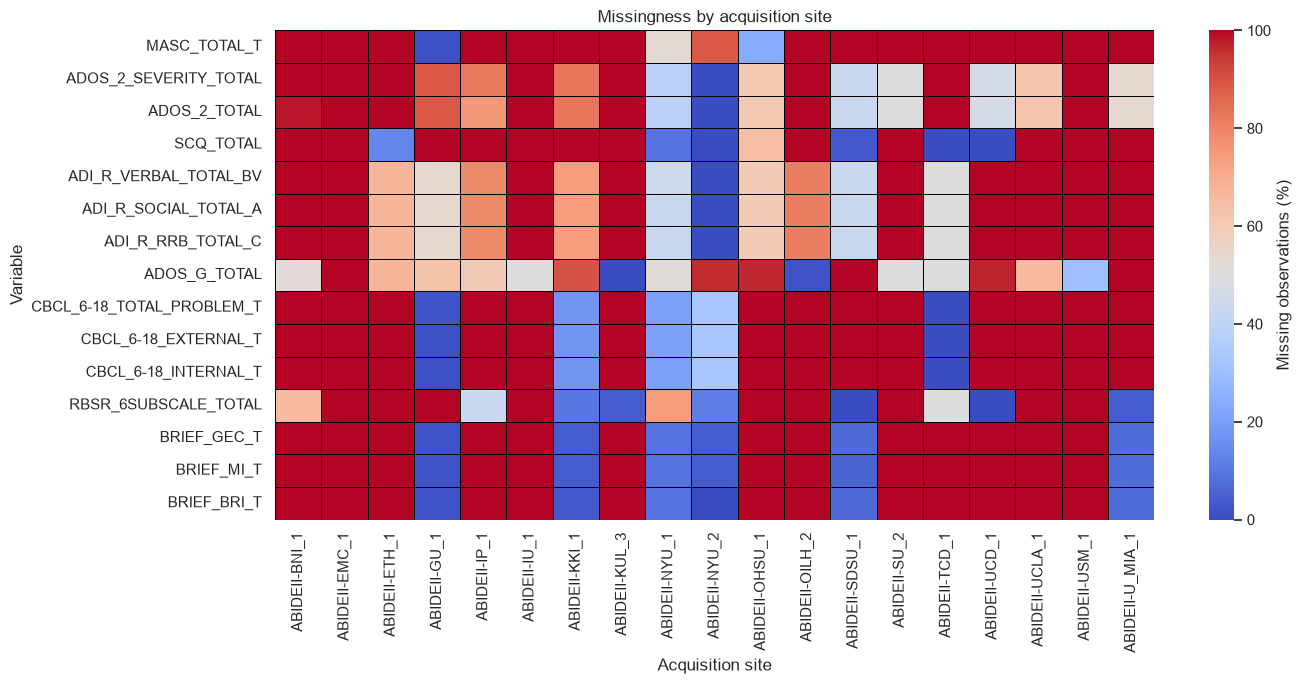

In [33]:
top_missing_variables = (
    missing_summary
    .query("n_missing > 0")
    .head(15)
    .index
)

missing_by_site = (
    phenotypes[top_missing_variables]
    .isna()
    .groupby(phenotypes["SITE_ID"], observed=True)
    .mean()
    .mul(100)
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    missing_by_site.T,
    cmap="coolwarm",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="black",
    cbar_kws={"label": "Missing observations (%)"},
    
)

plt.xlabel("Acquisition site")
plt.ylabel("Variable")
plt.title("Missingness by acquisition site")
plt.tight_layout()

#### Interpret the heatmap

1. Is missingness approximately equal across acquisition sites?
2. Can you identify assessments that appear to have been collected only at particular sites?
3. What would happen to the representation of sites if we retained only complete participants?
4. Could acquisition site be related to both missingness and diagnosis?

### Design a complete-case dataset

Suppose we want to construct an analysis table containing only participants with complete data for a selected set of core variables.

Use the missingness heatmap to choose the variables that you consider essential. The tool reports how many participants remain and whether participant retention differs across acquisition sites.

There is no universally correct set of core variables: the choice must follow the research question.

:::{note}
This activity requires an executable Python kernel. Use the **Open in Colab** button at the top of the page to interact with the controls.
:::

In [ ]:
candidate_variables = [
    column
    for column in phenotypes.columns
    if column != "SUB_ID"
]

variable_options = [
    (
        f"{column} — {phenotypes[column].isna().mean() * 100:.1f}% missing",
        column,
    )
    for column in candidate_variables
]

core_selector = widgets.SelectMultiple(
    options=variable_options,
    value=(
        "SITE_ID",
        "DX_GROUP",
        "AGE_AT_SCAN",
        "SEX",
        "FIQ",
    ),
    description="Core variables:",
    rows=12,
    layout=widgets.Layout(width="95%"),
    style={"description_width": "initial"},
)

In [ ]:
def update_retention(core_variables):
    selected_variables = list(core_variables)

    if not selected_variables:
        print("Select at least one variable.")
        return

    complete_mask = (
        phenotypes[selected_variables]
        .notna()
        .all(axis=1)
    )

    n_original = len(phenotypes)
    n_retained = complete_mask.sum()

    summary = pd.DataFrame(
        {
            "Participants": [n_original, n_retained],
            "Percentage": [
                100,
                n_retained / n_original * 100,
            ],
        },
        index=[
            "Original dataset",
            "Complete cases",
        ],
    )

    display(summary.round(1))

    total_by_site = (
        phenotypes
        .groupby("SITE_ID", observed=True)
        .size()
    )

    retained_by_site = (
        phenotypes.loc[complete_mask]
        .groupby("SITE_ID", observed=True)
        .size()
        .reindex(total_by_site.index, fill_value=0)
    )

    site_retention = (
        retained_by_site
        .div(total_by_site)
        .mul(100)
        .sort_values()
    )

    plt.figure(figsize=(11, 5))
    site_retention.plot.bar(color="steelblue")

    plt.axhline(
        n_retained / n_original * 100,
        color="darkred",
        linestyle="--",
        label="Overall retention",
    )

    plt.xlabel("Acquisition site")
    plt.ylabel("Participants retained (%)")
    plt.ylim(0, 105)
    plt.title("Complete-case retention by acquisition site")
    plt.legend()
    plt.tight_layout()
    plt.show()


retention_output = widgets.interactive_output(
    update_retention,
    {"core_variables": core_selector},
)

display(
    widgets.VBox(
        [
            core_selector,
            retention_output,
        ]
    )
)

### Your decision

Construct two possible analysis datasets:

1. A **minimal** dataset retaining as many participants as possible.
2. A **richer** dataset containing additional behavioral information.

For each selection, record:

- the selected variables;
- the number of retained participants;
- whether retention differs between sites;
- which scientific information was sacrificed.

Which dataset would you use to investigate relationships between demographic variables and diagnosis? Would the same selection be appropriate for studying symptom severity?

```{dropdown} Answer for Q4
Missingness can also depend on diagnosis. For example, some autism-specific assessments may have been administered primarily to participants in the autism group.
```

In [34]:
# Can you find scores that were collected only for diagnosed participants?
missing_by_diagnosis = (
    phenotypes[top_missing_variables]
    .isna()
    .groupby(phenotypes["DX_GROUP"], observed=True)
    .mean()
    .mul(100)
)

missing_by_diagnosis.T.round(1)

DX_GROUP,1,2
MASC_TOTAL_T,81.4,79.9
ADOS_2_SEVERITY_TOTAL,49.7,99.7
ADOS_2_TOTAL,48.8,99.7
SCQ_TOTAL,70.4,76.6
ADI_R_VERBAL_TOTAL_BV,42.2,100.0
ADI_R_SOCIAL_TOTAL_A,42.0,100.0
ADI_R_RRB_TOTAL_C,42.0,100.0
ADOS_G_TOTAL,42.2,92.2
CBCL_6-18_TOTAL_PROBLEM_T,66.4,62.1
CBCL_6-18_EXTERNAL_T,66.2,62.1


### Common approaches to missing data

There is no single correct method for handling every missing value. The appropriate choice depends on why values are missing, how much is missing, and how the variable will be used.

| Approach                         | Appropriate when                                                          | Main limitation                                         |
| -------------------------------- | ------------------------------------------------------------------------- | ------------------------------------------------------- |
| Keep missing values              | During EDA or when each analysis uses different variables                 | Some calculations and models cannot accept missing data |
| Drop incomplete rows             | Few rows are missing and missingness is plausibly unrelated to the result | Can reduce sample size and introduce selection bias     |
| Drop a variable                  | It is not essential and has insufficient usable data                      | Potentially discards important information              |
| Mean imputation                  | Rough baseline for approximately symmetric numerical data                 | Reduces variance and distorts relationships             |
| Median imputation                | Numerical data are skewed or contain outliers                             | Still reduces variability and ignores uncertainty       |
| Mode imputation                  | Few categorical values are missing                                        | Artificially increases the most common category         |
| Explicit “not recorded” category | Missingness itself may be informative                                     | Model may learn study procedures rather than biology    |
| Group-specific imputation        | Groups have meaningful distributional differences                         | Can cause leakage, especially if using the outcome      |
| KNN/model-based imputation       | Other variables strongly predict the missing value                        | More complex and may introduce model assumptions        |
| Multiple imputation              | Statistical inference must reflect imputation uncertainty                 | More complex and produces multiple datasets             |
| Missingness indicator            | Whether a value is missing may carry information                          | May encode site or acquisition artifacts                |


#### Removing incomplete observations

The simplest approach is complete-case deletion: retain only rows that have values for every required variable.

The dataframe contains 39 variables, including several questionnaires that were collected only at some sites.

Predict before running: How many participants do you expect would remain if we required complete data for all 39 variables?

In [35]:
core_variables = [
    "SITE_ID",
    "DX_GROUP",
    "AGE_AT_SCAN",
    "SEX",
    "FIQ",
]

retention_comparison = pd.DataFrame(
    {
        "dataset": [
            "Original dataset",
            "Complete for all 39 variables",
            "Complete for selected core variables",
        ],
        "n_participants": [
            len(phenotypes),
            len(phenotypes.dropna()),
            len(phenotypes.dropna(subset=core_variables)),
        ],
    }
)

retention_comparison["percent_retained"] = (
    retention_comparison["n_participants"]
    / len(phenotypes)
    * 100
)

retention_comparison.round(1)

,dataset,n_participants,percent_retained
0,Original dataset,1114,100.0
1,Complete for all 39 variables,1,0.1
2,Complete for selected core variables,1015,91.1


#### Questions

1. Why can requiring complete data for all variables remove almost every participant?
2. Why is deletion based on a specific analysis subset more reasonable?
3. Could the retained participants differ systematically from the excluded participants?
4. What should be checked before concluding that complete-case deletion is safe?

### Imputing a numerical variable

Imputation replaces missing observations with estimated values. As a simple example, we will replace missing `FIQ` values with the median observed FIQ.

We will work on a copy so that the original dataframe remains unchanged.

In [36]:
imputation_demo = phenotypes[
    ["SUB_ID", "SITE_ID", "DX_GROUP", "AGE_AT_SCAN", "SEX", "FIQ"]
].copy()

imputation_demo["FIQ_was_missing"] = imputation_demo["FIQ"].isna()

fiq_median = imputation_demo["FIQ"].median()
imputation_demo["FIQ_imputed"] = imputation_demo["FIQ"].fillna(fiq_median)

print(f"Median FIQ used for imputation: {fiq_median:.1f}")
print(f"Number of imputed observations: {imputation_demo['FIQ_was_missing'].sum()}")

Median FIQ used for imputation: 112.0
Number of imputed observations: 99


In [37]:
pd.DataFrame(
    {
        "Original FIQ": imputation_demo["FIQ"].describe(),
        "Median-imputed FIQ": imputation_demo["FIQ_imputed"].describe(),
    }
).round(2)

,Original FIQ,Median-imputed FIQ
count,1015.00,1114.00
mean,111.02,111.11
std,15.48,14.78
min,49.00,49.00
25%,101.00,103.00
50%,112.00,112.00
75%,122.00,120.00
max,151.00,151.00


```{dropdown} Important limitation

Median imputation solves the computational problem of missing values, but it does not reconstruct the unobserved measurements.

It introduces a concentration of observations at the median, usually reduces the estimated variance, and can weaken relationships between FIQ and other variables.
```

We filled the values without changing the distribution a lot. 
What would happen if we implemented this for all variables? Try it yourself!

### Handling missing categories

For a categorical variable, possible approaches include:

- replacing missing values with the most frequent category;
- creating an explicit category such as `"Not recorded"`;
- excluding the variable or incomplete participants.

An explicit missing category is useful when the absence of a value may itself be informative. However, it may also allow a model to learn differences between sites or data-collection procedures.

In [38]:
imputation_demo["CURRENT_MED_STATUS"] = phenotypes["CURRENT_MED_STATUS"]

imputation_demo["CURRENT_MED_STATUS_filled"] = (
    imputation_demo["CURRENT_MED_STATUS"]
    .astype("object")
    .fillna("Not recorded")
    .astype("category")
)

imputation_demo[
    ["CURRENT_MED_STATUS", "CURRENT_MED_STATUS_filled"]
].value_counts(dropna=False)

CURRENT_MED_STATUS  CURRENT_MED_STATUS_filled
0.0                 0.0                          824
1.0                 1.0                          167
nan                 Not recorded                 123
0.0                 1.0                            0
                    Not recorded                   0
1.0                 0.0                            0
                    Not recorded                   0
nan                 0.0                            0
                    1.0                            0
Name: count, dtype: int64

#### Question

Suppose medication status is missing mainly at one acquisition site. What might a classification model learn from the `"Not recorded"` category?

```{dropdown} Answer

The model may use `"Not recorded"` as an indirect indicator of acquisition site.

If site composition also differs between diagnostic groups, the model could appear to predict diagnosis while partly learning where the participant was scanned.
```

### Common approach:

For the exploratory analysis (as done here), we will not immediately impute or delete all missing values. Instead, we will:

1. preserve the original phenotype table;
2. report the available sample size for each variable;
3. examine whether missingness differs by site or diagnosis;
4. select variables according to the specific analysis;
5. perform deletion or imputation only when required.

**For later machine-learning analyses**, imputation parameters must be estimated using the training data only. Calculating an imputation value from the complete dataset before cross-validation would allow information from the test participants to influence preprocessing and would constitute data leakage.

## 5. Distributions and feature correlations

Summary statistics describe variables using only a few numbers. Visualizing their distributions can reveal information that the mean and standard deviation may hide, including:

- skewness;
- multiple peaks;
- restricted ranges;
- unusual observations;
- differences between participant groups.

We will first examine individual variables and then investigate relationships between features.

### Explore numerical distributions

A histogram divides the observed range into intervals called **bins** and counts the observations within each interval.

The choice of bin width matters. Too few bins can hide important structure, while too many bins can make random variation appear meaningful.

Use the controls below to select a variable and change the number of histogram bins.

Before changing the controls, predict:

1. What information will disappear when very few bins are used?
2. What happens when the number of bins becomes very large?
3. Will the same number of bins be suitable for age, IQ, and questionnaire scores?

The histogram below runs entirely in your browser. It needs no Python kernel, so it also works on the published course website.

<iframe
  title="Interactive histogram of ABIDE-II variable distributions"
  src="../../_static/widgets/app/index.html?config=../configs/eda_histogram.json"
  loading="lazy"
  width="100%"
  height="680"
  style="width: 100%; border: none;"
></iframe>


### Questions

Choose at least three variables.

1. Which distribution is most symmetric?
2. Which distribution appears most skewed?
3. Which variables are discrete scores rather than continuous measurements?
4. Did changing the number of bins alter your interpretation?
5. For which variable was the KDE curve potentially misleading?